In [2]:
import torch
import torchvision
import numpy as np
from PIL import Image   #用于图像处理
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader,random_split
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [3]:
#自定义数据集类型
class ImageDataSet(Dataset):
    def __init__(self, image_dir, transform=None):
        self.main_dir = image_dir
        self.transform = transform
        self.image_names = os.listdir(image_dir)

    def __len__(self):
        return len(self.image_names)

    #传入图片ID 获取数据集元素(X,y)  不是一次性加载 选择性加载 防止爆内存
    def __getitem__(self, idx):
        #1.根据索引号 获得图片完整路径
        image_loc = os.path.join(self.main_dir, self.image_names[idx])
        #2.使用PIL打开图片
        image = Image.open(image_loc).convert('RGB')
        #3.利用transform转化
        if self.transform:
            tensor_image = self.transform(image)
        else:
            raise ValueError('transform is not defined')
        #4.向原始图像增加随机噪声
        noise_factor = 0.5
        noise_image = tensor_image + noise_factor * torch.randn_like(tensor_image)
        noise_image = torch.clamp(noise_image, 0., 1.)
        return noise_image, tensor_image

In [4]:
import torchvision.transforms as T #图像预处理

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

transform=T.Compose([
    T.Resize((68, 68)),
    T.ToTensor()
])

In [5]:
#1.创建数据集
full_dataset=ImageDataSet(image_dir='../common/dataset/',transform=transform)
print(len(full_dataset))

24853


In [6]:
#2.划分数据集
train_dataset,test_dataset=random_split(full_dataset,[0.75,0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [7]:
#3.创建dataloader
batch_size=32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,drop_last=True)#丢弃最后一批除不尽的数据
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last=False)

In [8]:
for X,y in train_loader:
    print(X.shape)
    print(y.shape)
    break

torch.Size([32, 3, 68, 68])
torch.Size([32, 3, 68, 68])


In [9]:
#定义神经网络结构
import torch.nn as nn
class ConvDenoiser(nn.Module):
    def __init__(self):
        super(ConvDenoiser, self).__init__()
        #编码器
        #三个卷积层
        self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2=nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv3=nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1)
        #通用池化层 没有参数 不存在反向传播问题
        self.pool=nn.MaxPool2d(kernel_size=2, stride=2)
        #解码器
        #三个转置卷积层
        self.t_conv1=nn.ConvTranspose2d(in_channels=8, out_channels=8, kernel_size=3, stride=2, padding=0,output_padding=0)
        self.t_conv2=nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=2, stride=2, padding=0,output_padding=0)
        self.t_conv3=nn.ConvTranspose2d(in_channels=16, out_channels=32, kernel_size=2, stride=2, padding=0,output_padding=0)
        #普通卷积层
        self.conv_out=nn.Conv2d(in_channels=32, out_channels=3, kernel_size=3, stride=1, padding=1)

    def forward(self,x):
        #编码
        x=self.conv1(x)
        x=torch.relu(x)
        x=self.pool(x)

        x=self.conv2(x)
        x=torch.relu(x)
        x=self.pool(x)

        x=self.conv3(x)
        x=torch.relu(x)
        x=self.pool(x)

        #解码
        x=self.t_conv1(x)
        x=torch.relu(x)

        x=self.t_conv2(x)
        x=torch.relu(x)

        x=self.t_conv3(x)
        x=torch.relu(x)

        #最终卷积
        x=self.conv_out(x)
        x=torch.sigmoid(x)
        return x


In [10]:
model=ConvDenoiser()
print(model)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2))
  (t_conv2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [11]:
x=torch.randn(1,3,68,68)
y=model(x)
print(y.shape)

torch.Size([1, 3, 68, 68])


In [12]:
#定义损失函数和优化器
loss=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [13]:
#定义超参数
epoch_num=5
model=model.to(device)
for epoch in range(1, epoch_num + 1):
    train_loss = 0.0
    model.train()
    print(f"\n===== Epoch [{epoch}/{epoch_num}] 开始 =====")

    for noise_imgs, tensor_imgs in train_loader:
        #数据移动到设备
        noise_imgs = noise_imgs.to(device)
        tensor_imgs = tensor_imgs.to(device)
        #前向传播
        outputs = model(noise_imgs)
        #计算损失
        loss_value = loss(outputs, tensor_imgs)
        #反向传播与优化
        loss_value.backward()
        optimizer.step()
        optimizer.zero_grad()
        #累加损失
        train_loss += loss_value.item()
    this_loss = train_loss / len(train_loader)
    print(f"✅ Epoch [{epoch}/{epoch_num}] 完成, 平均损失: {this_loss:.4f}")


===== Epoch [1/5] 开始 =====
✅ Epoch [1/5] 完成, 平均损失: 0.0383

===== Epoch [2/5] 开始 =====
✅ Epoch [2/5] 完成, 平均损失: 0.0153

===== Epoch [3/5] 开始 =====
✅ Epoch [3/5] 完成, 平均损失: 0.0133

===== Epoch [4/5] 开始 =====
✅ Epoch [4/5] 完成, 平均损失: 0.0122

===== Epoch [5/5] 开始 =====
✅ Epoch [5/5] 完成, 平均损失: 0.0116


In [14]:
#验证模型训练效果
#从测试数据加载器获取一个批次的测试图像数据
loader_iter=iter(test_loader)
noise_imgs,original_imgs=next(loader_iter)
print(noise_imgs.shape)
print(original_imgs.shape)

torch.Size([32, 3, 68, 68])
torch.Size([32, 3, 68, 68])


In [15]:
#开始测试
model=model.to(device)
noise_imgs=noise_imgs.to(device)
outputs=model(noise_imgs)
print(outputs.shape)

torch.Size([32, 3, 68, 68])


In [16]:
#变化数据 准备绘图
#1.噪声图像
noise_imgs=noise_imgs.permute(0,2,3,1).detach().cpu().numpy()
print('noise_imgs.shape',noise_imgs.shape)
#2.去噪图像
outputs=outputs.permute(0,2,3,1).detach().cpu().numpy()
print('outputs.shape',outputs.shape)
#3.原始图像
original_imgs=original_imgs.permute(0,2,3,1).cpu().numpy()
print('original_imgs.shape',original_imgs.shape)

noise_imgs.shape (32, 68, 68, 3)
outputs.shape (32, 68, 68, 3)
original_imgs.shape (32, 68, 68, 3)


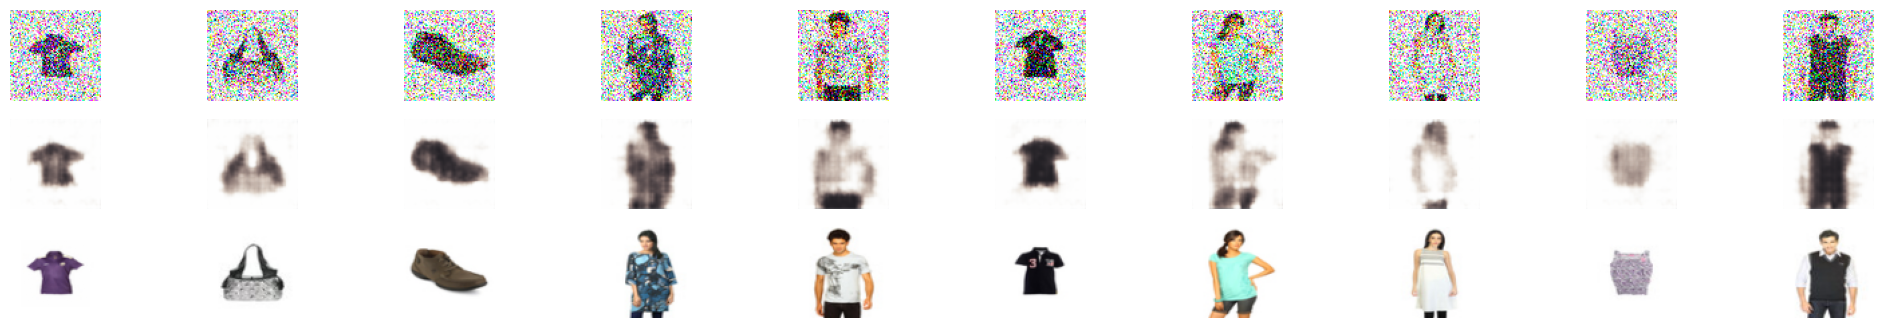

In [17]:
#画图
fig,axes=plt.subplots(3,10,figsize=(25,4))
for imgs,row in zip([noise_imgs,outputs,original_imgs],axes):
    for img,ax in zip(imgs,row):
        ax.imshow(img)
        ax.axis('off')
plt.show()